In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: c:\users\hp\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# load the excel file
file_path = "customer_churn_classification.xlsx"

# See available sheets
excel_file = pd.ExcelFile(file_path)
print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Customer data', 'Data dictionary']


In [4]:
# Load Customer sheet
df = pd.read_excel(file_path, sheet_name="Customer data")

print("Shape:", df.shape)
display(df.head())

Shape: (500, 12)


,customer_id,age_years,tenure_months,monthly_fee_inr,weekly_usage_hours,support_tickets_6m,late_payments_6m,discount_percent,auto_pay,satisfaction_score,competitor_offer,churned
0,C0001,39,50,800,11.5,3,1,20,1,9,1,0
1,C0002,58,20,1100,16.6,0,0,0,0,9,1,0
2,C0003,43,9,1350,14.6,3,0,0,1,7,0,0
3,C0004,42,40,850,13.5,6,1,5,1,5,0,1
4,C0005,26,44,800,11.8,5,3,5,0,4,0,1


In [5]:
# Inspect the dataset
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["churned"].value_counts())

Columns:
['customer_id', 'age_years', 'tenure_months', 'monthly_fee_inr', 'weekly_usage_hours', 'support_tickets_6m', 'late_payments_6m', 'discount_percent', 'auto_pay', 'satisfaction_score', 'competitor_offer', 'churned']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    object 
 1   age_years           500 non-null    int64  
 2   tenure_months       500 non-null    int64  
 3   monthly_fee_inr     500 non-null    int64  
 4   weekly_usage_hours  500 non-null    float64
 5   support_tickets_6m  500 non-null    int64  
 6   late_payments_6m    500 non-null    int64  
 7   discount_percent    500 non-null    int64  
 8   auto_pay            500 non-null    int64  
 9   satisfaction_score  500 non-null    int64  
 10  competitor_offer    500 non-null    int64  
 11  churned 

In [6]:
# Separate X and y
# Target
y = df["churned"]

# Features
X = df.drop(columns=["churned", "customer_id"])

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (500, 10)
y shape: (500,)


,age_years,tenure_months,monthly_fee_inr,weekly_usage_hours,support_tickets_6m,late_payments_6m,discount_percent,auto_pay,satisfaction_score,competitor_offer
0,39,50,800,11.5,3,1,20,1,9,1
1,58,20,1100,16.6,0,0,0,0,9,1
2,43,9,1350,14.6,3,0,0,1,7,0
3,42,40,850,13.5,6,1,5,1,5,0
4,26,44,800,11.8,5,3,5,0,4,0


0    0
1    0
2    0
3    1
4    1
Name: churned, dtype: int64

In [7]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining churn distribution:")
print(y_train.value_counts())

print("\nTest churn distribution:")
print(y_test.value_counts())

Training samples: 400
Test samples: 100

Training churn distribution:
churned
0    288
1    112
Name: count, dtype: int64

Test churn distribution:
churned
0    72
1    28
Name: count, dtype: int64


In [8]:
# Create the five models
models = {

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Gaussian Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])
}

In [9]:
# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

KNN trained successfully.
Gaussian Naive Bayes trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Logistic Regression trained successfully.


In [11]:
# Evaluate all models
results = []

predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.75,0.565217,0.464286,0.509804
1,Gaussian Naive Bayes,0.78,0.600000,0.642857,0.620690
2,Decision Tree,0.75,0.565217,0.464286,0.509804
3,Random Forest,0.86,0.750000,0.750000,0.750000
4,Logistic Regression,0.82,0.656250,0.750000,0.700000



KNN
[[62 10]
 [15 13]]


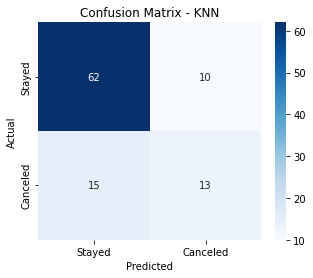


Gaussian Naive Bayes
[[60 12]
 [10 18]]


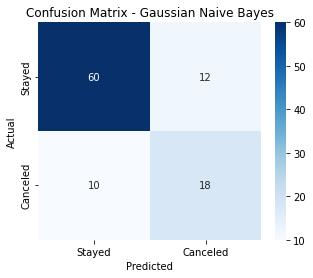


Decision Tree
[[62 10]
 [15 13]]


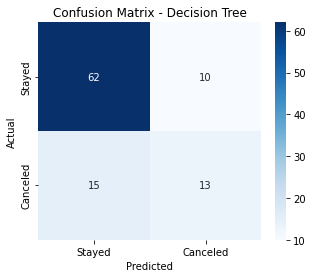


Random Forest
[[65  7]
 [ 7 21]]


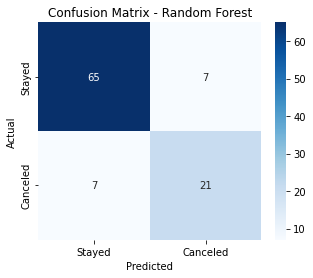


Logistic Regression
[[61 11]
 [ 7 21]]


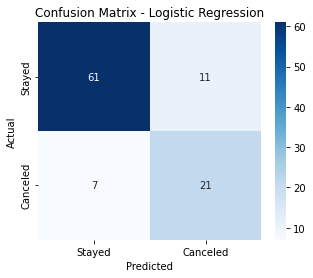

In [12]:
# Confusion matrices
for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(cm)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Canceled"],
        yticklabels=["Stayed", "Canceled"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")

    plt.show()

In [13]:
# Classification reports
for name, y_pred in predictions.items():

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Stayed", "Canceled"]
        )
    )



KNN
              precision    recall  f1-score   support

      Stayed       0.81      0.86      0.83        72
    Canceled       0.57      0.46      0.51        28

    accuracy                           0.75       100
   macro avg       0.69      0.66      0.67       100
weighted avg       0.74      0.75      0.74       100



Gaussian Naive Bayes
              precision    recall  f1-score   support

      Stayed       0.86      0.83      0.85        72
    Canceled       0.60      0.64      0.62        28

    accuracy                           0.78       100
   macro avg       0.73      0.74      0.73       100
weighted avg       0.79      0.78      0.78       100



Decision Tree
              precision    recall  f1-score   support

      Stayed       0.81      0.86      0.83        72
    Canceled       0.57      0.46      0.51        28

    accuracy                           0.75       100
   macro avg       0.69      0.66      0.67       100
weighted avg       0.74      

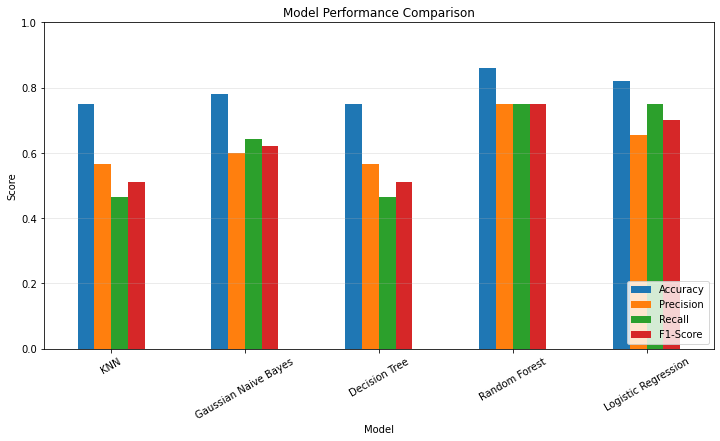

In [14]:
# Compare the models visually
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [15]:
# Which model catches the most cancellations?
best_recall_model = results_df.loc[
    results_df["Recall"].idxmax()
]

print("Model with highest recall:")
print(best_recall_model)

print(
    f"\n{best_recall_model['Model']} has the highest recall "
    f"of {best_recall_model['Recall']:.2%}."
)

Model with highest recall:
Model        Random Forest
Accuracy              0.86
Precision             0.75
Recall                0.75
F1-Score              0.75
Name: 3, dtype: object

Random Forest has the highest recall of 75.00%.


In [16]:
# Which model produces the fewest false alarms?
false_positive_results = []

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    false_positive_results.append({
        "Model": name,
        "False Positives": fp,
        "True Negatives": tn,
        "False Negatives": fn,
        "True Positives": tp
    })

fp_df = pd.DataFrame(false_positive_results)

display(fp_df)

best_fp_model = fp_df.loc[
    fp_df["False Positives"].idxmin()
]

print(
    f"\nFewest false alarms: {best_fp_model['Model']}"
)
print(
    f"False positives: {best_fp_model['False Positives']}"
)

,Model,False Positives,True Negatives,False Negatives,True Positives
0,KNN,10,62,15,13
1,Gaussian Naive Bayes,12,60,10,18
2,Decision Tree,10,62,15,13
3,Random Forest,7,65,7,21
4,Logistic Regression,11,61,7,21



Fewest false alarms: Random Forest
False positives: 7


In [17]:
# Compare TP, FP, TN and FN
display(fp_df)

,Model,False Positives,True Negatives,False Negatives,True Positives
0,KNN,10,62,15,13
1,Gaussian Naive Bayes,12,60,10,18
2,Decision Tree,10,62,15,13
3,Random Forest,7,65,7,21
4,Logistic Regression,11,61,7,21


In [18]:
# Tune KNN
k_values = list(range(1, 16, 2))

knn_cv_results = []

for k in k_values:

    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    knn_cv_results.append({
        "K": k,
        "Mean F1": scores.mean()
    })

knn_cv_df = pd.DataFrame(knn_cv_results)

display(knn_cv_df)

,K,Mean F1
0,1,0.546173
1,3,0.581033
2,5,0.556325
3,7,0.517955
4,9,0.513532
5,11,0.459635
6,13,0.453827
7,15,0.406259


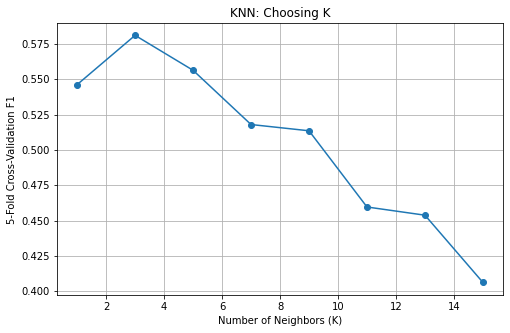

In [19]:
# Plot KNN K values
plt.figure(figsize=(8, 5))

plt.plot(
    knn_cv_df["K"],
    knn_cv_df["Mean F1"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("5-Fold Cross-Validation F1")
plt.title("KNN: Choosing K")

plt.grid(True)
plt.show()

In [20]:
# Find the best K:
best_k = knn_cv_df.loc[
    knn_cv_df["Mean F1"].idxmax(),
    "K"
]

print("Best K:", int(best_k))

Best K: 3


In [21]:
# Train KNN using the best K
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=int(best_k)
    ))
])

best_knn.fit(X_train, y_train)

best_knn_pred = best_knn.predict(X_test)

print("KNN with best K")
print("----------------")

print("Accuracy :", accuracy_score(y_test, best_knn_pred))
print("Precision:", precision_score(y_test, best_knn_pred))
print("Recall   :", recall_score(y_test, best_knn_pred))
print("F1 Score :", f1_score(y_test, best_knn_pred))

KNN with best K
----------------
Accuracy : 0.76
Precision: 0.6
Recall   : 0.42857142857142855
F1 Score : 0.5


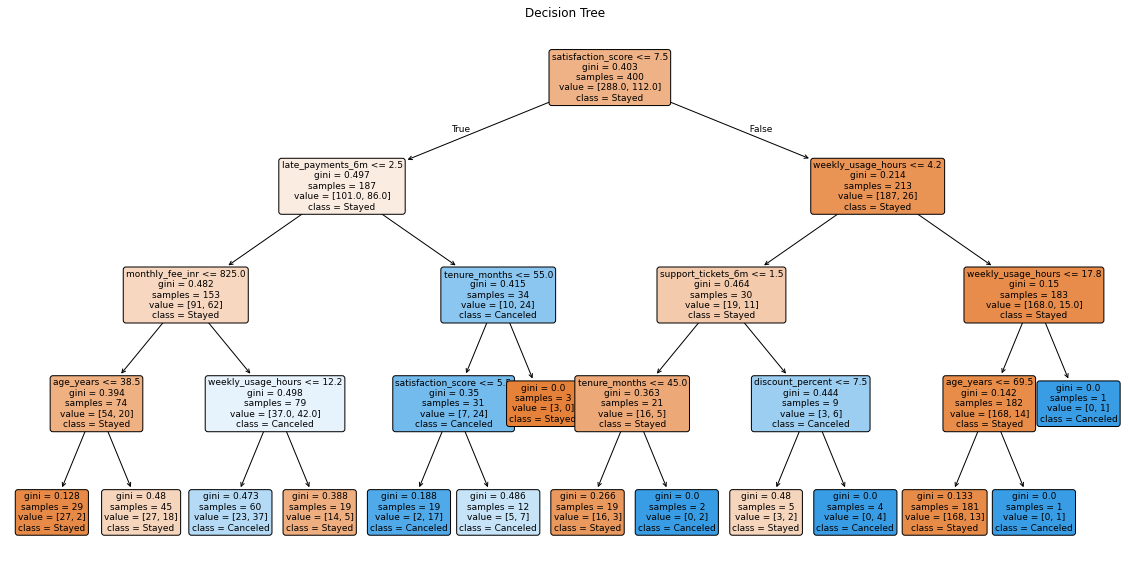

In [22]:
# Display a small Decision Tree
tree_model = models["Decision Tree"]

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Stayed", "Canceled"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree")
plt.show()

In [23]:
# Random Forest feature importance
rf_model = models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(rf_importance)

,Feature,Importance
3,weekly_usage_hours,0.185862
8,satisfaction_score,0.155158
1,tenure_months,0.126848
2,monthly_fee_inr,0.117922
0,age_years,0.111010
4,support_tickets_6m,0.101524
5,late_payments_6m,0.086130
6,discount_percent,0.054207
9,competitor_offer,0.039493
7,auto_pay,0.021847


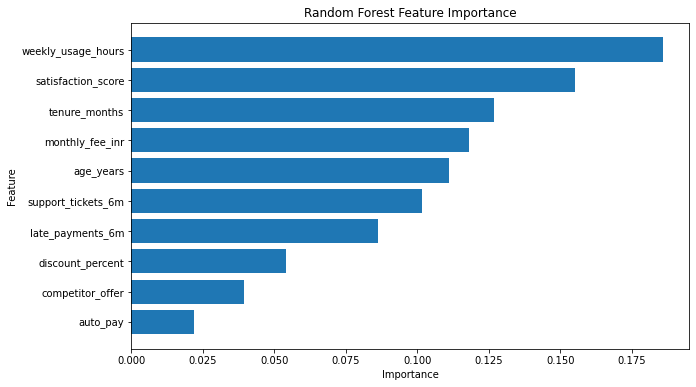

In [24]:
# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [25]:
# Logistic Regression coefficients
logistic_pipeline = models["Logistic Regression"]

logistic_model = logistic_pipeline.named_steps["logistic"]

logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(logistic_coefficients)

,Feature,Coefficient,Absolute Coefficient
3,weekly_usage_hours,-0.779512,0.779512
4,support_tickets_6m,0.753621,0.753621
5,late_payments_6m,0.702986,0.702986
9,competitor_offer,0.665575,0.665575
2,monthly_fee_inr,0.546110,0.546110
8,satisfaction_score,-0.522834,0.522834
1,tenure_months,-0.518022,0.518022
7,auto_pay,-0.333217,0.333217
0,age_years,0.144534,0.144534
6,discount_percent,-0.039146,0.039146


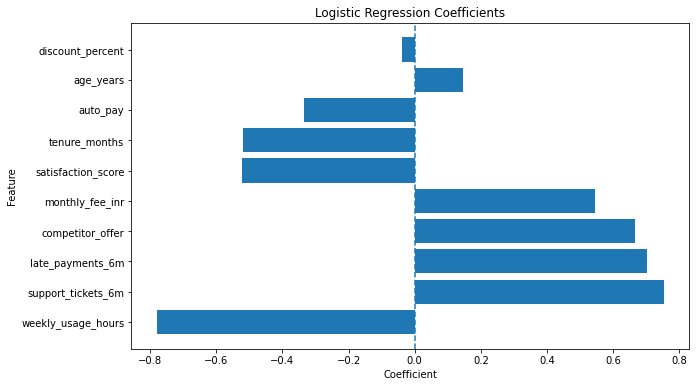

In [26]:
# Plot Logistic Regression coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    logistic_coefficients["Feature"],
    logistic_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")

plt.show()

In [27]:
# Identify best models
best_accuracy = results_df.loc[
    results_df["Accuracy"].idxmax()
]

best_precision = results_df.loc[
    results_df["Precision"].idxmax()
]

best_recall = results_df.loc[
    results_df["Recall"].idxmax()
]

best_f1 = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("Best Accuracy:")
print(best_accuracy["Model"], best_accuracy["Accuracy"])

print("\nBest Precision:")
print(best_precision["Model"], best_precision["Precision"])

print("\nBest Recall:")
print(best_recall["Model"], best_recall["Recall"])

print("\nBest F1:")
print(best_f1["Model"], best_f1["F1-Score"])

Best Accuracy:
Random Forest 0.86

Best Precision:
Random Forest 0.75

Best Recall:
Random Forest 0.75

Best F1:
Random Forest 0.75


In [28]:
# Final retention campaign analysis
print("=" * 70)
print("CUSTOMER RETENTION CAMPAIGN ANALYSIS")
print("=" * 70)

print(
    f"\nModel catching the most cancellations: "
    f"{best_recall['Model']}"
)

print(
    f"Recall: {best_recall['Recall']:.2%}"
)

print(
    f"\nModel with highest precision: "
    f"{best_precision['Model']}"
)

print(
    f"Precision: {best_precision['Precision']:.2%}"
)

print(
    f"\nModel with highest overall accuracy: "
    f"{best_accuracy['Model']}"
)

print(
    f"Accuracy: {best_accuracy['Accuracy']:.2%}"
)

print("\nRecommendation:")

print(
    "If the main goal is to catch as many customers likely to cancel "
    "as possible, prioritize the model with the highest recall."
)

print(
    "If the main goal is to minimize unnecessary retention offers, "
    "prioritize the model with fewer false positives / higher precision."
)

CUSTOMER RETENTION CAMPAIGN ANALYSIS

Model catching the most cancellations: Random Forest
Recall: 75.00%

Model with highest precision: Random Forest
Precision: 75.00%

Model with highest overall accuracy: Random Forest
Accuracy: 86.00%

Recommendation:
If the main goal is to catch as many customers likely to cancel as possible, prioritize the model with the highest recall.
If the main goal is to minimize unnecessary retention offers, prioritize the model with fewer false positives / higher precision.
